In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import manifold

In [2]:
# read the data (skip the first row and first two columns (1st: index, 2nd: timestamp))
#skiprows deletes header(0,1,2...)
#usecols range deletes time stamp column
good_s0_t0 = np.loadtxt('./data/preprocessed/final_interpolated_good_s_000_t_001.csv', delimiter=',', skiprows=1, usecols=range(2,29))
mild_s0_t0 = np.loadtxt('./data/preprocessed/final_interpolated_mild_s_000_t_001.csv', delimiter=',', skiprows=1, usecols=range(2,29))
bad_s0_t0 = np.loadtxt('./data/preprocessed/final_interpolated_bad_s_000_t_002.csv', delimiter=',', skiprows=1, usecols=range(2,29))

In [3]:
def select_acc(sensor_data):
    return np.hstack([sensor_data[:, :3], sensor_data[:, 9:12], sensor_data[:, 18:21]])

def select_gyr(sensor_data):
    return np.hstack([sensor_data[:, 3:6], sensor_data[:, 12:15], sensor_data[:, 21:24]])

def select_mag(sensor_data):
    return np.hstack([sensor_data[:, 6:9], sensor_data[:, 15:18], sensor_data[:, 24:27]])

good_acc, mild_acc, bad_acc = select_acc(good_s0_t0), select_acc(mild_s0_t0), select_acc(bad_s0_t0)
# good_mag, mild_mag, bad_mag = select_mag(good_s0_t0), select_mag(mild_s0_t0), select_mag(bad_s0_t0)

# good_ft = np.hstack([good_acc, good_mag])
# mild_ft = np.hstack([mild_acc, mild_mag])
# bad_ft = np.hstack([bad_acc, bad_mag])

good_ft = np.hstack([good_acc])
mild_ft = np.hstack([mild_acc])
bad_ft = np.hstack([bad_acc])


X = np.vstack([good_ft, mild_ft, bad_ft])
y = np.hstack([0 * np.ones(good_ft.shape[0]), 1 * np.ones(mild_ft.shape[0]), 2 * np.ones(bad_ft.shape[0])]).T.astype(np.int64)

In [4]:
pca = PCA(n_components=3)
pca.fit(X)
X_pca = pca.transform(X)
y = y.astype(np.int64)

In [5]:
print(good_acc.shape, mild_acc.shape, bad_acc.shape)
print(X.shape, y.shape)

(1484, 9) (1489, 9) (1483, 9)
(4456, 9) (4456,)


In [6]:
def plot3d_embedding(X, y, elev=50, azim=100):
    fig = plt.figure(1, figsize=(8, 6))
    plt.clf()

    ax = fig.add_subplot(111, projection="3d", elev=elev, azim=azim)
    ax.set_position([0, 0, 0.95, 1])
    plt.cla()

    for name, label in [("Good", 0), ("Mild", 1), ("Bad", 2)]:
        txt_colors = {0: "green", 1: "yellow", 2: "green"}
        ax.text3D(
            X[y == label, 0].mean(),
            X[y == label, 1].mean() + 10*label,
            X[y == label, 2].mean(),
            name,
            horizontalalignment="center",
            bbox=dict(alpha=0.9, edgecolor=txt_colors[label], facecolor=txt_colors[label]),
        )

    # Reorder the labels to have colors matching the cluster results
    y_tmp = np.choose(y, [1, 2, 0]).astype(float)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_tmp, edgecolor="w")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])

    plt.show()

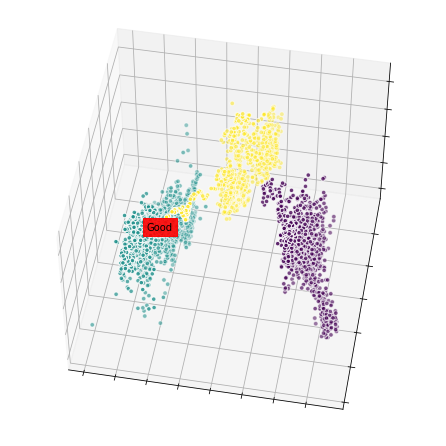

In [7]:
plot3d_embedding(X_pca, y)

In [9]:
# MDS
import sklearn
from sklearn import manifold
print(sklearn.__version__)
md_scaling = manifold.MDS(
    n_components=3,
    max_iter=50,
    n_init=4,
    random_state=0,
    normalized_stress=False,
)
X_mds = md_scaling.fit_transform(X)

1.2.0


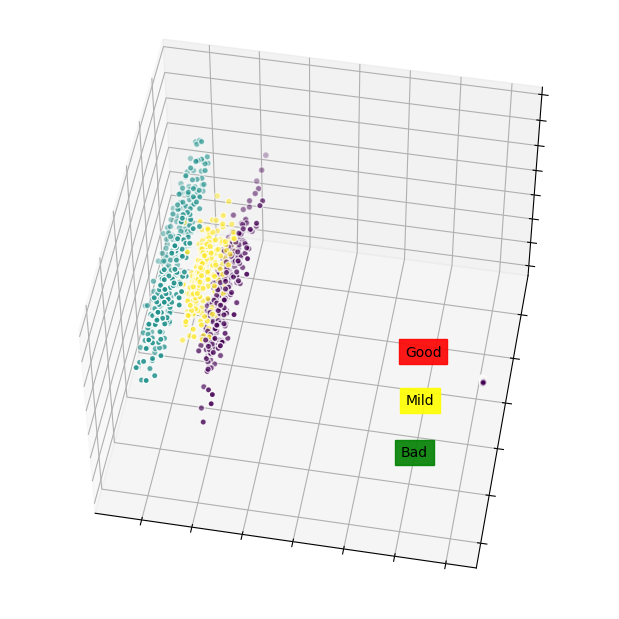

In [111]:
plot3d_embedding(X_mds, y)

In [112]:
t_sne = manifold.TSNE(
    n_components=3,
    perplexity=30,
    init="random",
    n_iter=250,
    random_state=0,
)
X_t_sne = t_sne.fit_transform(X)

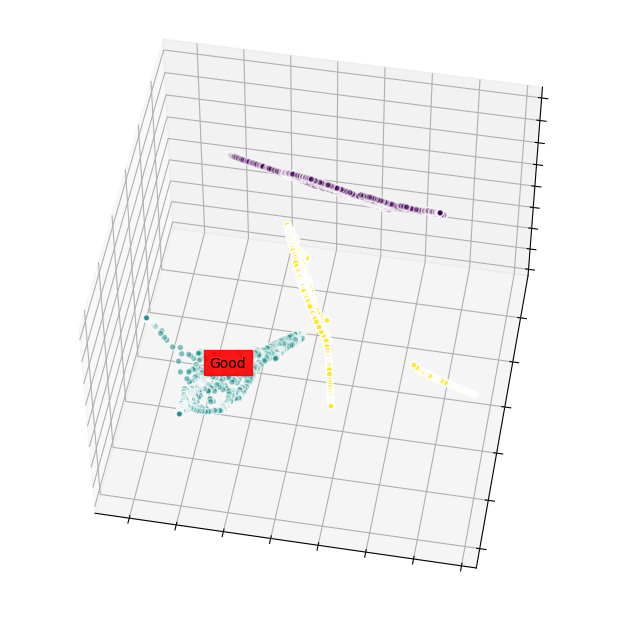

In [113]:
plot3d_embedding(X_t_sne, y)

In [114]:
params = {
    "n_neighbors": 30,
    "n_components": 3,
    "eigen_solver": "auto",
    "random_state": 0,
}

lle_standard = manifold.LocallyLinearEmbedding(method="standard", **params)
X_standard = lle_standard.fit_transform(X)

lle_ltsa = manifold.LocallyLinearEmbedding(method="ltsa", **params)
X_ltsa = lle_ltsa.fit_transform(X)

# lle_hessian = manifold.LocallyLinearEmbedding(method="hessian", **params)
# X_hessian = lle_hessian.fit_transform(X)

# lle_mod = manifold.LocallyLinearEmbedding(method="modified", **params)
# X_mod = lle_mod.fit_transform(X)

/opt/homebrew/lib/python3.10/site-packages/scipy/sparse/linalg/_eigen/arpack/arpack.py:935: LinAlgWarning: Diagonal number 161 is exactly zero. Singular matrix.
  self.M_lu = lu_factor(M)


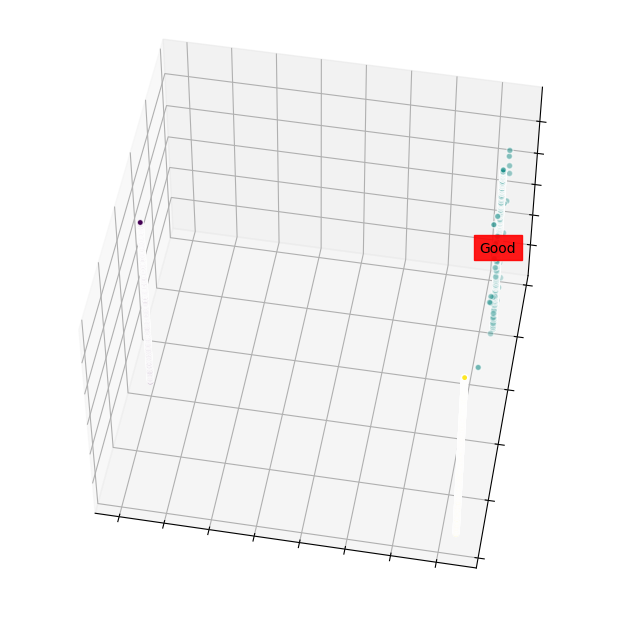

In [115]:
plot3d_embedding(X_standard, y)

In [132]:
pca = PCA(n_components=6)
pca.fit(good_s0_t0)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.90485557 0.03166615 0.02093758 0.01228793 0.01020741 0.00754656]
[1947.27401871  364.27976513  296.2106338   226.9220905   206.82124604
  177.83286897]


In [ ]:
t_sne = manifold.TSNE(
    n_components=n_components,
    perplexity=30,
    init="random",
    n_iter=250,
    random_state=0,
)
S_t_sne = t_sne.fit_transform(S_points)

plot_2d(S_t_sne, S_color, "T-distributed Stochastic  \n Neighbor Embedding")

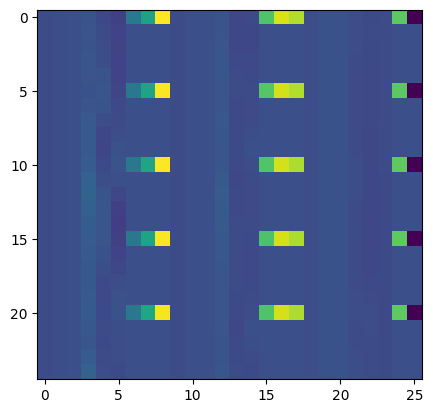

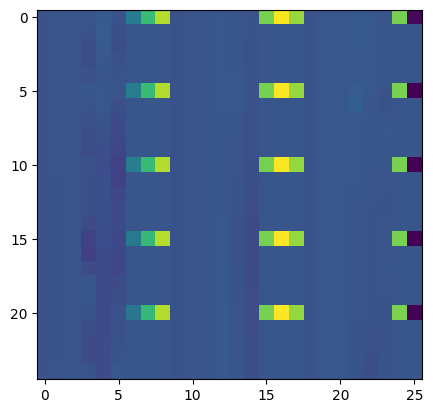

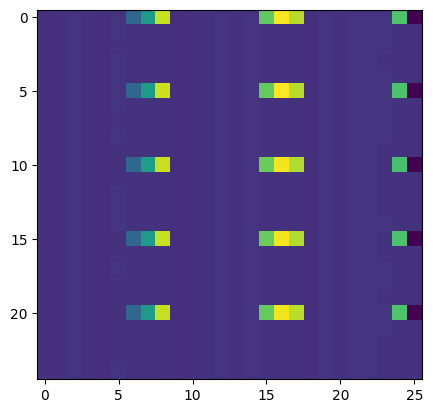

In [30]:
plt.figure()
plt.imshow(good_s0_t0[:25, :])
plt.figure()
plt.imshow(mild_s0_t0[:25, :])
plt.figure()
plt.imshow(bad_s0_t0[:25, :])